# Example loading a batch of data using the PyTorch dataloaders

Package requirements:
- pytorch
- numpy
- pandas
- tqdm
- h5py
- matplotlib
- xarray
- cartopy
- skyfield
- src/helio_dt/datasets/ directory of dataset_x.py files
- src/helio_dt/events/events.py

In [8]:
# Imports
import torch
import datetime
import helio_dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from helio_dt.datasets.dataset_jpld import JPLD
from helio_dt.datasets.dataset_sequences import Sequences
from helio_dt.datasets.dataset_union import Union
from helio_dt.datasets.dataset_sunmoongeometry import SunMoonGeometry
from helio_dt.datasets.dataset_quasidipole import QuasiDipole
from helio_dt.datasets.dataset_celestrak import CelesTrak
from helio_dt.datasets.dataset_omniweb import OMNIWeb, omniweb_all_columns
from helio_dt.datasets.dataset_set import SET, set_all_columns
from helio_dt.datasets.dataloader_cached import CachedDataLoader

from helio_dt.events.events import EventCatalog, validation_events_1, validation_events_2, validation_events_3, validation_events_4, validation_events_5

### Define some necessary functions

In [13]:
# Utility function to stack features as channels for input to a model
def stack_as_channels(features, image_size=(180,360)):
    if not isinstance(features, list) and not isinstance(features, tuple):
        raise ValueError('Expecting a list or tuple of features')
    c = []
    for f in features:
        if not isinstance(f, torch.Tensor):
            f = torch.tensor(f, dtype=torch.float32)
        if f.ndim == 0:
            f = f.expand(image_size)
            f = f.unsqueeze(0)
        elif f.ndim == 1:
            f = f.view(-1, 1, 1)
            f = f.expand((-1,) + image_size)
        elif f.shape == image_size:
            f = f.unsqueeze(0)  # add channel dimension
        else:
            raise ValueError('Expecting 0d or 1d features, or 2d features with shape equal to image_size')
        c.append(f)
    c = torch.cat(c, dim=0)
    return c


# Yeo-Johnson transformation
# Based on https://github.com/scikit-learn/scikit-learn/blob/c5497b7f7eacfaff061cf68e09bcd48aa93d4d6b/sklearn/preprocessing/_data.py#L3480
def yeojohnson(X, lambdas):
    if X.shape != lambdas.shape:
        raise ValueError("X and lambdas must have the same shape.")
    if X.ndim != 1:
        raise ValueError("X must be a 1D tensor.")
    
    # Ensure that no lambdas are 0 or 2 to avoid division by zero
    if torch.isclose(lambdas, torch.zeros_like(lambdas), atol=1e-8).any() or torch.isclose(lambdas, torch.tensor(2.0, dtype=lambdas.dtype, device=lambdas.device), atol=1e-8).any():
        raise ValueError("Lambdas must not contain 0 or 2 to avoid division by zero.")

    out = torch.zeros_like(X)
    pos = X >= 0  # binary mask

    # CAUTION: this assumes a lambda will never be 0 or 2
    out[pos] = (torch.pow(X[pos] + 1, lambdas[pos]) - 1) / lambdas[pos]
    out[~pos] = -(torch.pow(-X[~pos] + 1, 2 - lambdas[~pos]) - 1) / (2 - lambdas[~pos])
    return out


# Yeo-Johnson inverse transformation
# Based on https://github.com/scikit-learn/scikit-learn/blob/c5497b7f7eacfaff061cf68e09bcd48aa93d4d6b/sklearn/preprocessing/_data.py#L3424C1-L3431C41
def yeojhonson_inverse(X, lambdas):
    if X.shape != lambdas.shape:
        raise ValueError("X and lambdas must have the same shape.")
    if X.ndim != 1:
        raise ValueError("X must be a 1D tensor.")
    X_original = torch.zeros_like(X)
    pos = X >= 0

    # Ensure that no lambdas are 0 or 2 to avoid division by zero
    if torch.isclose(lambdas, torch.zeros_like(lambdas), atol=1e-8).any() or torch.isclose(lambdas, torch.tensor(2.0, dtype=lambdas.dtype, device=lambdas.device), atol=1e-8).any():
        raise ValueError("Lambdas must not contain 0 or 2 to avoid division by zero.")


    # CAUTION: this assumes a lambda will never be 0 or 2
    X_original[pos] = (X[pos] * lambdas[pos] + 1) ** (1 / lambdas[pos]) - 1
    X_original[~pos] = 1 - (-(2 - lambdas[~pos]) * X[~pos] + 1) ** (1 / (2 - lambdas[~pos]))

    return X_original

## Load a single batch of data
Example of just loading a single batch of JPLD data and plotting it

In [10]:
# Create a dataset
dataset_jpld_dir = '/projects/mlia-active-data/helio-surrogate/data/jpld/webdataset'

date_start = datetime.datetime(2015, 1, 1)
date_end = datetime.datetime(2015, 1, 10)

dataset_jpld = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end)


JPLD
Directory      : /projects/mlia-active-data/helio-surrogate/data/jpld/webdataset
Rewind minutes : 50
Loading tar files index from cache: /projects/mlia-active-data/helio-surrogate/data/jpld/webdataset/tar_files_index_55b85b53d5c7cda2eb36e1bf37c24de8
Start date : 2015-01-01 00:00:00
End date   : 2015-01-10 00:00:00
Delta      : 15 minutes
Loading dates from cache: /projects/mlia-active-data/helio-surrogate/data/jpld/webdataset/dates_index_2015-01-01T00:00:00_2015-01-10T00:00:00
TEC maps total    : 864
TEC maps available: 864
TEC maps dropped  : 0


In [11]:
# Load the JPLD map corresponding to date datetime.datetime(2015, 1, 4, 12, 30)
date = datetime.datetime(2015, 1, 4, 12, 30)
tec_map, tec_date = dataset_jpld[date]
print(tec_map.shape, tec_date)

torch.Size([1, 180, 360]) 2015-01-04T12:30:00


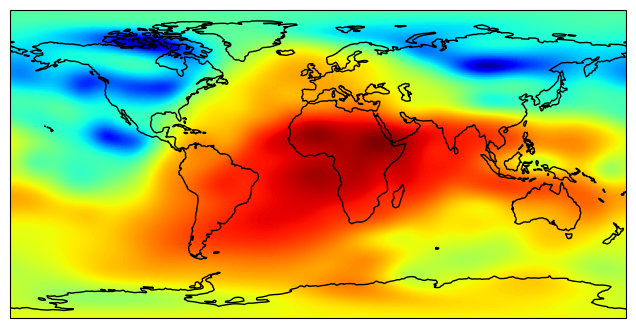

In [15]:
# Plot the TEC map
# Create a GeoAxes instance with a specific projection
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(
    tec_map[0],
    extent=[-180, 180, -90, 90],
    origin='upper',
    cmap='jet',
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Train and Validation setup
Example of setting up a dataset for training and validation using the JPLD, OMNIWeb, and the SunMoon datasets, excluding certain events for validation.

In [17]:
# Initialize variables
date_start = datetime.datetime(2018, 4, 1)
date_end = datetime.datetime(2018, 5, 1)
event_catalog = EventCatalog(events_csv_file_name='./../data/events.csv')
valid_event_id = ["G0H3-201804202100"]
image_size = (180, 360)
context_window = 2 # Number of time steps of context used in model
prediction_window = 1 # Number of time steps to predict
training_sequence_length = context_window + prediction_window
delta_minutes = 15 # 15-minute cadence 
date_dilation = 16 # Use 16x dilation for 15-min data to get 4-hour context

date_exclusions = []
datasets_omniweb_valid = []
datasets_jpld_valid = []
datasets_sunmoon_valid = []

dataset_omniweb_dir = '/projects/mlia-active-data/helio-surrogate/data/omniweb' #'/path/to/omniweb/data/'
dataset_jpld_dir = '/projects/mlia-active-data/helio-surrogate/data/jpld/webdataset' #'/path/to/jpld/data/'

# Process validation events
for event_id in valid_event_id:
    print('Excluding event ID: {}'.format(event_id))

    if event_id not in event_catalog:
        raise ValueError('Event ID {} not found in EventCatalog'.format(event_id))

    # EventCatalog[event_id] is a dict with keys:
    # 'date_start': date_start,
    # 'date_end': date_end,
    # 'duration': duration,
    # 'max_kp': max_kp,
    # 'time_steps': time_steps

    event = event_catalog[event_id]
    exclusion_start = datetime.datetime.fromisoformat(event['date_start']) - datetime.timedelta(minutes=context_window * delta_minutes)
    exclusion_end = datetime.datetime.fromisoformat(event['date_end'])
    date_exclusions.append((exclusion_start, exclusion_end))
    print('Exclusion start: {}, end: {}'.format(exclusion_start, exclusion_end))

    datasets_omniweb_valid.append(OMNIWeb(dataset_omniweb_dir, date_start=exclusion_start, date_end=exclusion_end, return_as_image_size=image_size))
    datasets_jpld_valid.append(JPLD(dataset_jpld_dir, date_start=exclusion_start, date_end=exclusion_end))
    datasets_sunmoon_valid.append(SunMoonGeometry(date_start=exclusion_start, date_end=exclusion_end))

# Create validation dataset
dataset_jpld_valid = Union(datasets=datasets_jpld_valid)
dataset_omniweb_valid = Union(datasets=datasets_omniweb_valid)
dataset_sunmoon_valid = Union(datasets=datasets_sunmoon_valid)

# Create training dataset excluding validation events
dataset_jpld_train = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)
dataset_omniweb_train = OMNIWeb(dataset_omniweb_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions, return_as_image_size=image_size)
dataset_sunmoon_train = SunMoonGeometry(date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)

# Create Sequence datasets
dataset_valid = Sequences(datasets=[dataset_jpld_valid, dataset_omniweb_valid, dataset_sunmoon_valid], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)
dataset_train = Sequences(datasets=[dataset_jpld_train, dataset_omniweb_train, dataset_sunmoon_train], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)


Excluding event ID: G0H3-201804202100
Exclusion start: 2018-04-20 20:30:00, end: 2018-05-05 21:00:00

OMNIWeb
File indices           : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_indices_15min.csv
File magnetic field    : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_solar_wind_15min.csv
Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns       

Filtering dates: 100%|██████████| 2880/2880 [00:00<00:00, 355334.48it/s]

Saving dates to cache: /projects/mlia-active-data/helio-surrogate/data/jpld/webdataset/dates_index_2018-04-01T00:00:00_2018-05-01T00:00:00_159b930a10c559ca4b00b6e9d0060ca6
TEC maps total    : 2,880
TEC maps available: 1,906
TEC maps dropped  : 974

OMNIWeb
File indices           : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_indices_15min.csv
File magnetic field    : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : /projects/mlia-active-data/helio-surrogate/data/omniweb/omniweb_solar_wind_15min.csv


Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Return as image size  : (180, 360)
Rows before processing: 498,625
Date exclusio

In [ ]:
# Load one batch of data and plot it